<a href="https://colab.research.google.com/github/tether007/DIP/blob/main/MPP_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

`Thermal Image
->
Simulated Damage
->
Mask Detection
->
Restored Image
->
PSNR / similarity score`

#1 . Initial data preprocessing
# Its basically sensor image -> detect corrupted part -> Mask gen -> prepare a Tensor rep. -> Feed it directly to DIP

In [ ]:
import torch

# Device agnostic code

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
device

'cuda'

# 2 . Imports and necessary packages

In [ ]:
import torch
from torch import nn
#vision libs
import torchvision

from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

#import visuaal stuff
import matplotlib.pyplot as plt
import cv2 as cv



In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("deepnewbie/flir-thermal-images-dataset")

print("Path to dataset files:", path)

100%|██████████| 15.3G/15.3G [15:03<00:00, 18.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/deepnewbie/flir-thermal-images-dataset/versions/1


In [ ]:
path

'/root/.cache/kagglehub/datasets/deepnewbie/flir-thermal-images-dataset/versions/1'

Checking path:
/root/.cache/kagglehub/datasets/deepnewbie/flir-thermal-images-dataset/versions/1/FLIR_ADAS_1_3/train/thermal_16_bit
Exists: True
Total TIFF files: 8862
Loading: /root/.cache/kagglehub/datasets/deepnewbie/flir-thermal-images-dataset/versions/1/FLIR_ADAS_1_3/train/thermal_16_bit/FLIR_06822.tiff
Shape: (512, 640)
Datatype: uint16


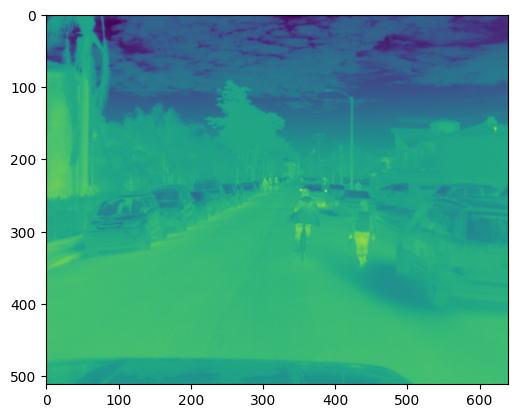

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

dataset_root = "/root/.cache/kagglehub/datasets/deepnewbie/flir-thermal-images-dataset/versions/1"

thermal_16_bit_dir = os.path.join(
    dataset_root,
    "FLIR_ADAS_1_3",
    "train",
    "thermal_16_bit"
)

print("Checking path:")
print(thermal_16_bit_dir)

print("Exists:", os.path.exists(thermal_16_bit_dir))

# List TIFF files
image_files = [
    f for f in os.listdir(thermal_16_bit_dir)
    if f.endswith(".tiff")
]

print("Total TIFF files:", len(image_files))

# Load first image
sample_image_path = os.path.join(
    thermal_16_bit_dir,
    image_files[0]
)

print("Loading:", sample_image_path)

# Read the image first
image = cv2.imread(sample_image_path, cv2.IMREAD_UNCHANGED)
plt.imshow(image)
print("Shape:", image.shape)
print("Datatype:", image.dtype)



In [ ]:
image  = cv2.imread(sample_image_path, cv2.IMREAD_UNCHANGED)

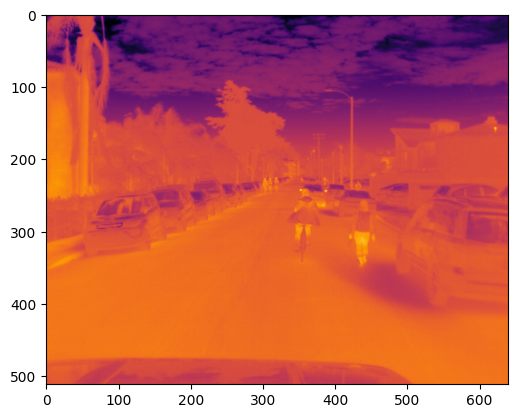

In [ ]:
plt.imshow(image,cmap="inferno")

In [ ]:
normalized = cv2.normalize(
    image,
    None,
    0,
    1,
    cv2.NORM_MINMAX,
    dtype=cv2.CV_32F
)

#3 . Adding Gausian noise to simulate for NOW

In [ ]:
import numpy as np

noise = np.random.normal(0, 0.02, normalized.shape)

corrupted = normalized + noise

corrupted = np.clip(corrupted, 0, 1)

corrupted = corrupted.astype(np.float32)

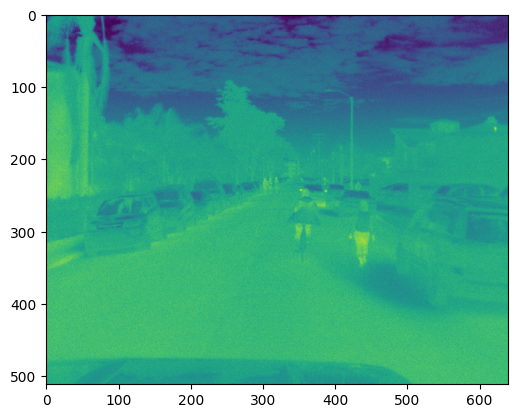

In [ ]:
plt.imshow(corrupted)

(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

<Figure size 1000x700 with 0 Axes>

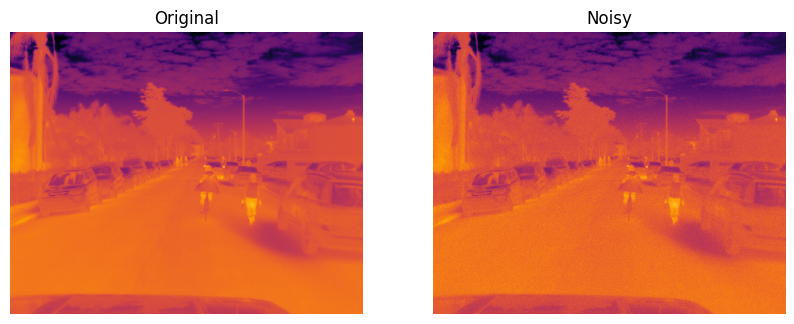

In [ ]:
plt.figure(figsize=(10,7))
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

# Original Image
axes[0].imshow(normalized, cmap='inferno')
axes[0].set_title("Original")
axes[0].axis('off')

# Noisy Image
axes[1].imshow(corrupted, cmap='inferno')
axes[1].set_title("Noisy")
axes[1].axis('off')


## 3.1 Adding missing(to simulate inpainting )

In [ ]:
corrupted2 = corrupted.copy()

corrupted2[150:300, 100:200] = 0


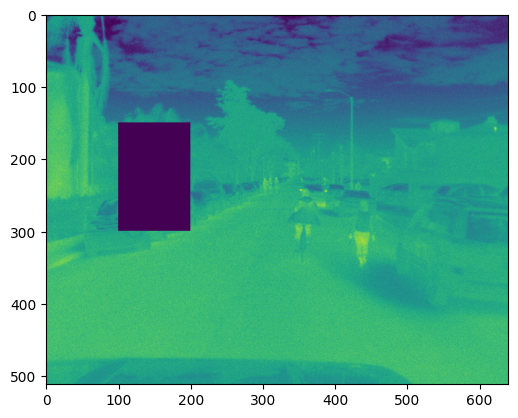

In [ ]:
plt.imshow(corrupted2)

(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

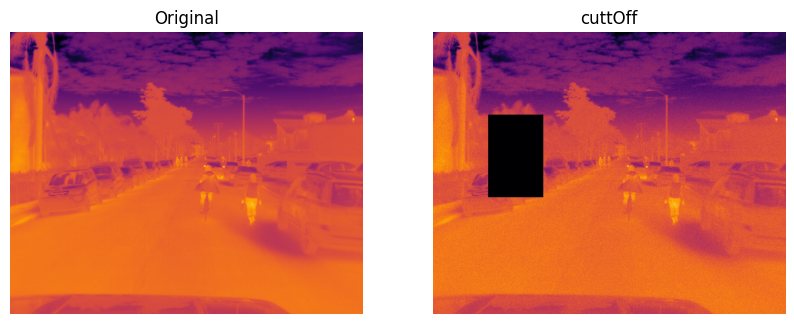

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

# Original Image
axes[0].imshow(normalized, cmap='inferno')
axes[0].set_title("Original")
axes[0].axis('off')

# missing region Image
axes[1].imshow(corrupted2, cmap='inferno')
axes[1].set_title("cuttOff")
axes[1].axis('off')

#4 . Creating a simple Mask for the given image
*. As simple as valid pixel -> 1, else 0





In [ ]:
mask = (corrupted2 > 0).astype(np.float32)

In [ ]:
mask

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], dtype=float32)

# 5 . Img to Tensor (Highly crucial since it was numpy till now , but from pytorch we need it in tensor)

* now we are worried about the "noiseful image"

## 5.1 . corr_Img -> tensor

In [ ]:
image_tensor = torch.tensor(corrupted).float()

In [ ]:
image_tensor = image_tensor.unsqueeze(0).unsqueeze(0)# adding an extra dimension for W and H

In [ ]:
print(image_tensor.min().item())
print(image_tensor.max().item())

0.0
1.0


##5.11 corr2_img->tensor

In [ ]:
corr2_tensor = torch.tensor(corrupted2).float()
corr2_tensor = corr2_tensor.unsqueeze(0).unsqueeze(0)

In [ ]:
print(corr2_tensor.min().item())
print(corr2_tensor.max().item())

0.0
1.0


## 5.2 . mask -> tensor

In [ ]:
mask_tensor = torch.tensor(mask).float()

## 5.3 . org_img -> tensor

In [ ]:
org_tensor = torch.tensor(image).float()

In [ ]:
org_tensor = org_tensor.unsqueeze(0).unsqueeze(0)

##6 . Visualizing all the tensors
* Tensor to Numpy and then viz

<Figure size 1000x700 with 0 Axes>

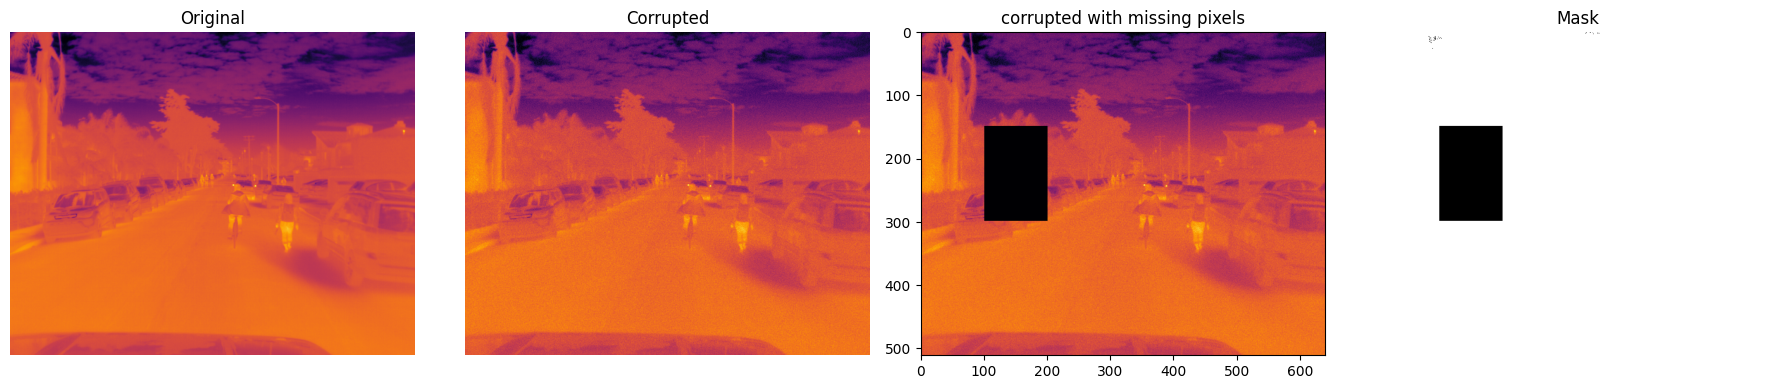

In [ ]:
original_np = org_tensor.squeeze().cpu().numpy()
corrupted_np = image_tensor.squeeze().cpu().numpy()
corrupted2_np = corr2_tensor.squeeze().cpu().numpy()
mask_np = mask_tensor.squeeze().cpu().numpy()

plt.figure(figsize=(10,7))
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Original
axes[0].imshow(original_np, cmap='inferno')
axes[0].set_title("Original")
axes[0].axis('off')

# Corrupted wiht noise
axes[1].imshow(corrupted_np, cmap='inferno')
axes[1].set_title("Corrupted")
axes[1].axis('off')

#corrupted with degradation(pixel missing)
axes[2].imshow(corrupted2, cmap="inferno")
axes[2].set_title("corrupted with missing pixels")
axes[1].axis('off')

# Mask
axes[3].imshow(mask_np, cmap='gray')
axes[3].set_title("Mask")
axes[3].axis('off')

plt.tight_layout()
plt.show()

#  To be Practical in the given sit. lets start with a Encoder-Decoder CNN

#7.0 . MODEL v_0

In [ ]:
import torch
import torch.nn as nn

class SimpleDIP(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 1, 3, padding=1)

        )

    def forward(self, x):
        return self.net(x)

In [ ]:
modelV1 = SimpleDIP()

In [ ]:
modelV1.state_dict

<bound method Module.state_dict of SimpleDIP(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)>

## 7.1 start here with our mini-scaled implementation

### DAC

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [ ]:
modelV1.to(device)

SimpleDIP(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)

### Move the tensors to device too

In [ ]:
original_tensor = org_tensor.to(device)

corrupted_tensor = corr2_tensor.to(device)

mask_tensor = mask_tensor.to(device)

### Random noice `z`

In [ ]:
z = torch.randn_like(corrupted_tensor).to(device)
print(z.min(), z.max())
print(corrupted_tensor.min().item())
print(corrupted_tensor.max().item())

tensor(-4.6916, device='cuda:0') tensor(4.4160, device='cuda:0')
0.0
1.0


### Optimizer(adam) for now

In [ ]:
optimizer = torch.optim.Adam(
    modelV1.parameters(),
    lr=0.001
)

## 8 . Training Loop

In [ ]:
num_iterations = 10000

for i in range(num_iterations):

    optimizer.zero_grad()

    # Forward pass
    output = modelV1(z)

    # calculate the loss
    loss = (
        ((output - corrupted_tensor) - mask_tensor) ** 2
    ).mean()
    # Optim zero grad
    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    # Print progress
    if i % 200 == 0:
        print(f"Iteration {i} | Loss: {loss.item()} | {(output.min().item(), output.max().item())}")

Iteration 0 | Loss: 2.4035375118255615 | (-0.19567757844924927, 0.07137295603752136)
Iteration 200 | Loss: 0.14832141995429993 | (0.22685889899730682, 2.0696463584899902)
Iteration 400 | Loss: 0.13301651179790497 | (0.2995390295982361, 1.7022873163223267)
Iteration 600 | Loss: 0.12834706902503967 | (0.36818593740463257, 1.892927885055542)
Iteration 800 | Loss: 0.12651829421520233 | (0.46928972005844116, 1.9729254245758057)
Iteration 1000 | Loss: 0.12390811741352081 | (0.5751967430114746, 2.0323855876922607)
Iteration 1200 | Loss: 0.12066888809204102 | (0.7090907692909241, 2.189826726913452)
Iteration 1400 | Loss: 0.11673400551080704 | (0.8006657361984253, 2.170668601989746)
Iteration 1600 | Loss: 0.11572368443012238 | (0.8070281744003296, 2.0973167419433594)
Iteration 1800 | Loss: 0.10954179614782333 | (0.8477411270141602, 2.174722909927368)
Iteration 2000 | Loss: 0.10670237988233566 | (0.8155546188354492, 2.2150566577911377)
Iteration 2200 | Loss: 0.10321257263422012 | (0.693293154239

# 9 . Viz after

In [ ]:
output_image = output.detach().cpu().squeeze().numpy()

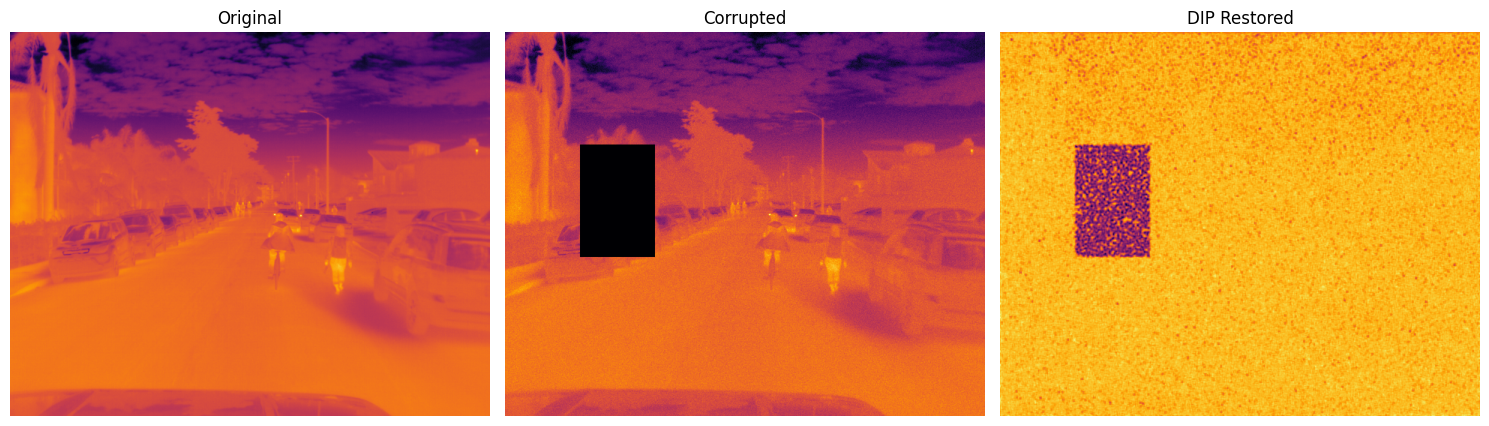

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Original
axes[0].imshow(
    org_tensor.cpu().squeeze(),
    cmap='inferno'
)
axes[0].set_title("Original")
axes[0].axis('off')

# Corrupted
axes[1].imshow(
    corr2_tensor.cpu().squeeze(),
    cmap='inferno'
)
axes[1].set_title("Corrupted")
axes[1].axis('off')

# Restored
axes[2].imshow(
    output_image,
    cmap='inferno'
)
axes[2].set_title("DIP Restored")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# 10 . Evaluation Metrics

In [ ]:
# !pip install torchmetrics

## 10.1 . PSNR(Peak Signal to noise ratio)

In [ ]:
from torchmetrics.image import PeakSignalNoiseRatio

psnr = PeakSignalNoiseRatio(data_range=1).to(device)


In [ ]:
print(original_tensor.device)

cuda:0


In [ ]:
output_tensor = torch.tensor(output_image).unsqueeze(0).unsqueeze(0).to(device).float()
print(output_tensor.device)
score = psnr(original_tensor, output_tensor)
print(f"PSNR score: {score.item():.4f}")

cuda:0
PSNR score: -77.1115


## 10.2 . SSIR(Structural similarity Index Measure)

In [ ]:
from torchmetrics.image import StructuralSimilarityIndexMeasure

ssim= StructuralSimilarityIndexMeasure().to(device)

In [ ]:
print(ssim(original_tensor,output_tensor))

tensor(0.0004, device='cuda:0')


In [ ]:
#could've worked more on here like normalising the tensors b/w (0-255 ) and (0 - 1)

print(original_tensor.min(), original_tensor.max())
print(output_tensor.min(), output_tensor.max())

tensor(6633., device='cuda:0') tensor(7627., device='cuda:0')
tensor(-1.1091, device='cuda:0') tensor(2.0649, device='cuda:0')


# MODEL V_1(A encoder - decoder approach)

#* . Apprach:
 1. normalize and get some new Img(or existing must be normalied properly) --->
 2. generate noise (z) --->
 3. hyperparams(loss , optim) --->
 4. early stopping mech -->
 5. training -->
 6. testing -->
 7. eval

In [ ]:
import torch
import torch.nn as nn

class DIP_V1(nn.Module):

    def __init__(self):
        super().__init__()

        self.enc1 = nn.Sequential(

            nn.Conv2d(
                1,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)

        )
        self.down1 = nn.Sequential(

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)

        )

        self.enc2 = nn.Sequential(

            nn.Conv2d(
                128,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                128,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)

        )

        self.down2 = nn.Sequential(

            nn.Conv2d(
                128,
                256,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)

        )
        self.bottleneck = nn.Sequential(

            nn.Conv2d(
                256,
                256,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                256,
                256,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                256,
                256,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)

        )
        self.up1 = nn.Sequential(

            nn.ConvTranspose2d(
                256,
                128,
                kernel_size=2,
                stride=2
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)

        )

        self.dec1 = nn.Sequential(

            nn.Conv2d(
                128,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                128,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)

        )
        self.up2 = nn.Sequential(

            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=2,
                stride=2
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)

        )

        self.dec2 = nn.Sequential(

            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)

        )
        self.output_layer = nn.Sequential(

            nn.Conv2d(
                64,
                1,
                kernel_size=1
            ),

            nn.Sigmoid()

        )

    def forward(self, x):
        x = self.enc1(x)
        x = self.down1(x)
        x = self.enc2(x)
        x = self.down2(x)
        # Bottleneck
        x = self.bottleneck(x)
        # Decoder
        x = self.up1(x)
        x = self.dec1(x)
        x = self.up2(x)
        x = self.dec2(x)
        # Output
        x = self.output_layer(x)
        return x

# 11 . Model V-1

In [ ]:
image = image.astype(np.float32)

image = (
    image - image.min()
) / (
    image.max() - image.min()
)

print(image.min())
print(image.max())

0.0
1.0


## 11.1 . Noise

In [ ]:
img = torch.tensor(image).float()

/tmp/ipykernel_1712/504568645.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  noisy_img = img + noise


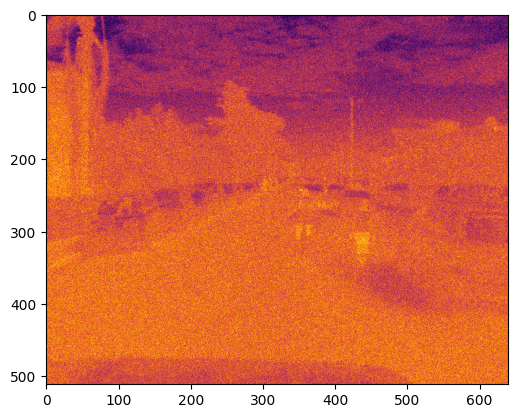

In [ ]:
noise_std = 0.10

noise = np.random.normal(
    0,
    noise_std,
    img.shape
)

noisy_img = img + noise
plt.imshow(noisy_img,cmap = 'inferno')

### Keeping it within image range

In [ ]:
noisy_img = np.clip(
    noisy_img,
    0,
    1
)

In [ ]:
original_tensor = (
    torch.tensor(img, dtype=torch.float32)
    .unsqueeze(0)
    .unsqueeze(0)
    .to(device)
)

noisy_tensor = (
    torch.tensor(noisy_img, dtype=torch.float32)
    .unsqueeze(0)
    .unsqueeze(0)
    .to(device)
)

/tmp/ipykernel_1712/3553230653.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(img, dtype=torch.float32)
/tmp/ipykernel_1712/3553230653.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(noisy_img, dtype=torch.float32)


In [ ]:
noisy_tensor.shape

torch.Size([1, 1, 512, 640])

# 12 . DIP_v1 Training Pipeline

## 12.1 . The instantiazied Model

In [ ]:
modelV1 = DIP_V1().to(device)

optimizer = torch.optim.Adam(
    modelV1.parameters(),
    lr=5e-4 #0.00001
)

criterion = nn.MSELoss().to(device) #loss basically

In [ ]:
#input to the network
z = torch.rand(
    1,
    1,
    512,
    640,
    device=device
)

In [ ]:
target = noisy_tensor.to(device)

## 12.2 . Pre-initialisation of the metrics PNSR and SSIM

In [ ]:

from torchmetrics.image import PeakSignalNoiseRatio
from torchmetrics.image import StructuralSimilarityIndexMeasure

psnr = PeakSignalNoiseRatio(data_range=1.0).to(device)

ssim = StructuralSimilarityIndexMeasure(
    data_range=1.0
).to(device)

In [ ]:
best_psnr = -float("inf")

best_ssim = 0.0

best_output = None

## 12.3 . The training Loop

In [ ]:
num_iterations = 200

snapshots = {}

snapshot_iters = [
    0,
    5,
    10,
    20,
    30,
    50,
    100,
    200
]

psnr_history = []
ssim_history = []
iter_history = []

for i in range(num_iterations):

    optimizer.zero_grad()

    z_noisy = z + 0.01 * torch.randn_like(z)

    output = modelV1(z_noisy)

    loss = criterion(
        output,
        target
    )

    loss.backward()

    optimizer.step()

    if i % 10 == 0:

        current_psnr = psnr(
            output,
            original_tensor
        ).item()

        current_ssim = ssim(
            output,
            original_tensor
        ).item()

        iter_history.append(i)
        psnr_history.append(current_psnr)
        ssim_history.append(current_ssim)

        if current_psnr > best_psnr:

            best_psnr = current_psnr
            best_ssim = current_ssim
            best_output = output.detach().clone()

        print(
            f"Iter {i:4d} | "
            f"Loss {loss.item():.6f} | "
            f"PSNR {current_psnr:.2f} | "
            f"SSIM {current_ssim:.4f}"
        )

    if i in snapshot_iters:

        snapshots[i] = (
            output
            .detach()
            .cpu()
            .clone()
        )

Iter    0 | Loss 0.067160 | PSNR 12.42 | SSIM 0.1153
Iter   10 | Loss 0.014438 | PSNR 23.24 | SSIM 0.7703
Iter   20 | Loss 0.011756 | PSNR 26.39 | SSIM 0.7819
Iter   30 | Loss 0.010678 | PSNR 28.07 | SSIM 0.8152
Iter   40 | Loss 0.009767 | PSNR 28.58 | SSIM 0.7531
Iter   50 | Loss 0.008743 | PSNR 27.34 | SSIM 0.6013
Iter   60 | Loss 0.007126 | PSNR 25.72 | SSIM 0.4227
Iter   70 | Loss 0.004918 | PSNR 23.47 | SSIM 0.2590
Iter   80 | Loss 0.003159 | PSNR 22.08 | SSIM 0.2003
Iter   90 | Loss 0.002073 | PSNR 21.09 | SSIM 0.1628
Iter  100 | Loss 0.001466 | PSNR 20.77 | SSIM 0.1521
Iter  110 | Loss 0.001127 | PSNR 20.54 | SSIM 0.1451
Iter  120 | Loss 0.000935 | PSNR 20.49 | SSIM 0.1439
Iter  130 | Loss 0.000839 | PSNR 20.28 | SSIM 0.1373
Iter  140 | Loss 0.000720 | PSNR 20.32 | SSIM 0.1385
Iter  150 | Loss 0.000662 | PSNR 20.34 | SSIM 0.1393
Iter  160 | Loss 0.000601 | PSNR 20.24 | SSIM 0.1361
Iter  170 | Loss 0.000566 | PSNR 20.22 | SSIM 0.1354
Iter  180 | Loss 0.000576 | PSNR 20.16 | SSIM 

## 12.4 . To see the denoising behaviour we can plot the given itereations over their PSNR

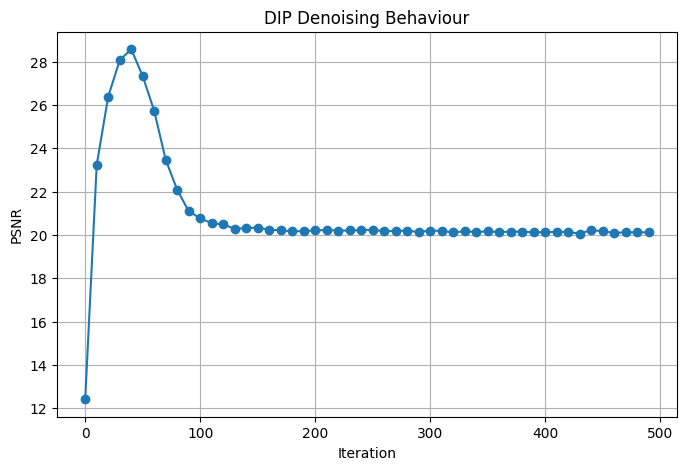

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    iter_history,
    psnr_history,
    marker='o'
)

plt.xlabel("Iteration")
plt.ylabel("PSNR")
plt.title("DIP Denoising Behaviour")

plt.grid(True)

plt.show()

## 12.5 . The best value is stored as Restored for modelV1

In [ ]:
restored_image = best_output

In [ ]:
final_psnr = psnr(
    restored_image,
    original_tensor
).item()

final_ssim = ssim(
    restored_image,
    original_tensor
).item()

print(f"Best PSNR : {final_psnr:.2f}")

print(f"Best SSIM : {final_ssim:.4f}")

Best PSNR : 28.58
Best SSIM : 0.7531


## 12.6 . Visualizing the ground truth

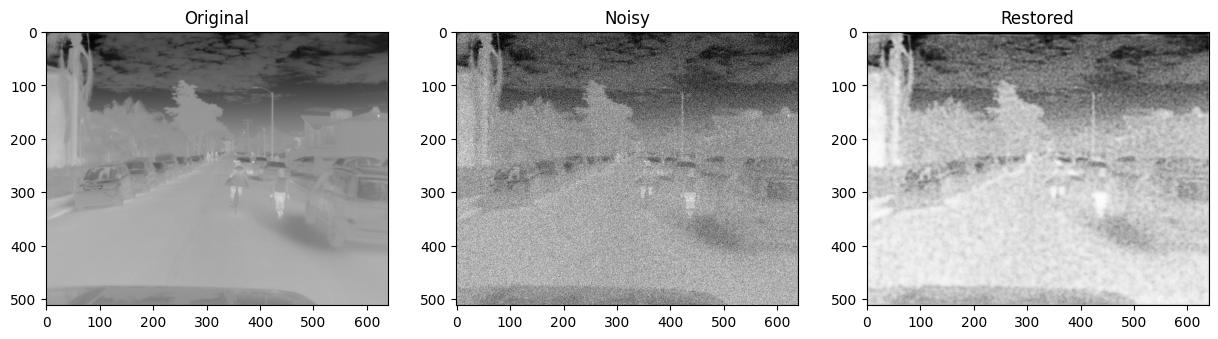

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(
    original_tensor[0,0].cpu(),
    cmap='gray'
)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(
    noisy_tensor[0,0].cpu(),
    cmap='gray'
)
plt.title("Noisy")

plt.subplot(1,3,3)
plt.imshow(
    restored_image[0,0].cpu(),
    cmap='gray'
)
plt.title("Restored")

plt.show()

In [ ]:
print(output.min(), output.max())

tensor(2.5018e-33, device='cuda:0', grad_fn=<MinBackward1>) tensor(0.9635, device='cuda:0', grad_fn=<MaxBackward1>)


In [ ]:
noisy_psnr = psnr(
    noisy_tensor,
    original_tensor
)

print(noisy_psnr)

tensor(20.0350, device='cuda:0')


In [ ]:
print(
    "Noisy PSNR:",
    psnr(
        noisy_tensor,
        original_tensor
    ).item()
)

print(
    "Noisy SSIM:",
    ssim(
        noisy_tensor,
        original_tensor
    ).item()
)

Noisy PSNR: 20.0350399017334
Noisy SSIM: 0.13093069195747375


## 12.7 . Vis. of iterations' op

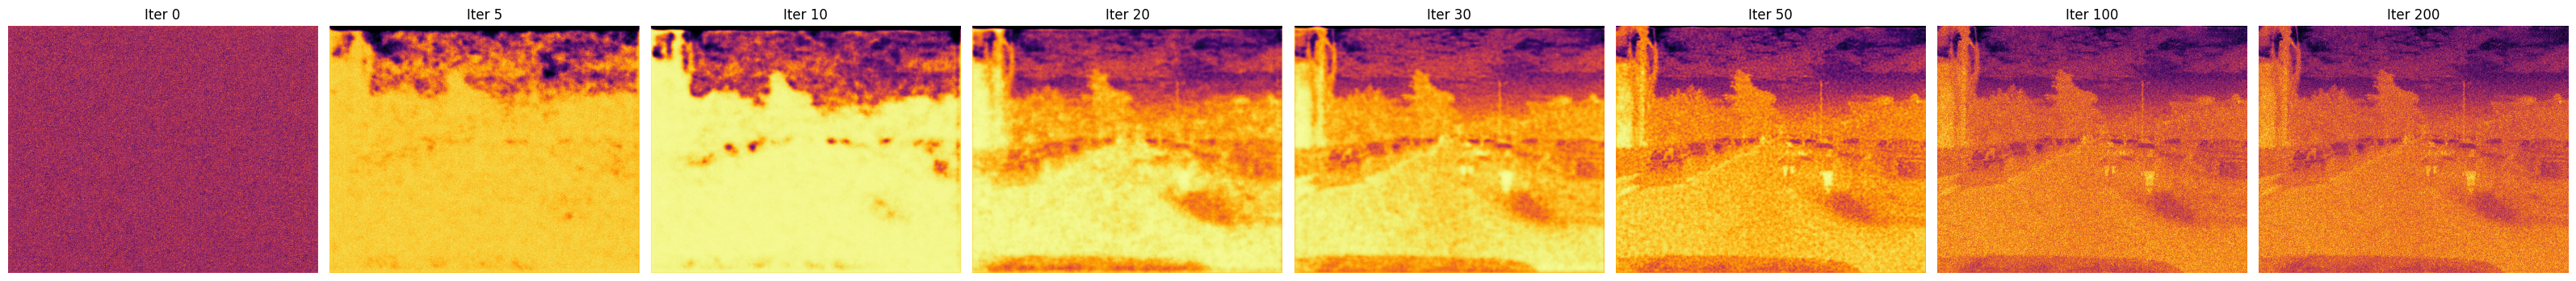

In [ ]:
import matplotlib.pyplot as plt

keys = sorted(snapshots.keys())

fig, axes = plt.subplots(
    1,
    len(keys),
    figsize=(4*len(keys),4)
)

if len(keys) == 1:
    axes = [axes]

for ax, k in zip(axes, keys):

    img = snapshots[k][0,0].numpy()

    ax.imshow(
        img,
        cmap="inferno"
    )

    ax.set_title(
        f"Iter {k}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

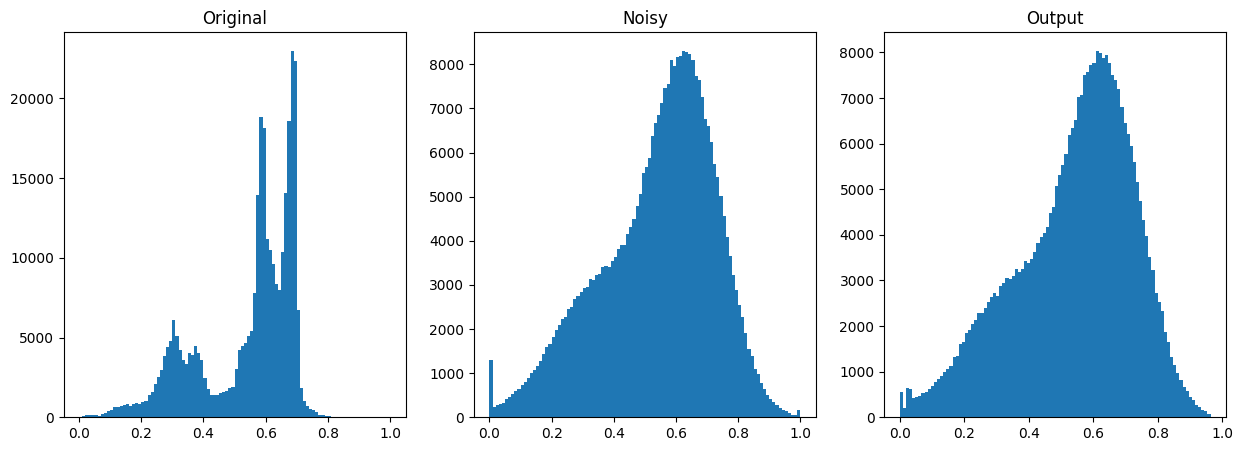

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(131)
plt.hist(
    original_tensor.cpu().numpy().flatten(),
    bins=100
)
plt.title("Original")

plt.subplot(132)
plt.hist(
    noisy_tensor.cpu().numpy().flatten(),
    bins=100
)
plt.title("Noisy")

plt.subplot(133)
plt.hist(
    output.detach().cpu().numpy().flatten(),
    bins=100
)
plt.title("Output")

plt.show()

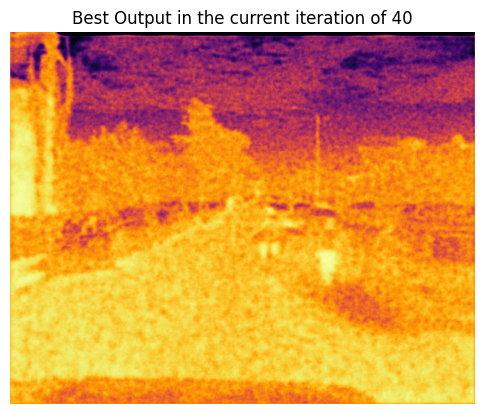

In [245]:
plt.figure(figsize=(6,6))

plt.imshow(
    best_output[0,0].cpu(),
    cmap='inferno'
)

plt.title("Best Output in the current iteration of 40")

plt.axis('off')

plt.show()